In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()


Saving Plant_1_Generation_Data.csv to Plant_1_Generation_Data.csv


In [2]:
uploaded = files.upload()

Saving Plant_1_Weather_Sensor_Data.csv to Plant_1_Weather_Sensor_Data.csv


Generation DATE_TIME:
0    15-05-2020 00:00
1    15-05-2020 00:00
2    15-05-2020 00:00
3    15-05-2020 00:00
4    15-05-2020 00:00
Name: DATE_TIME, dtype: object

Weather DATE_TIME:
0    2020-05-15 00:00:00
1    2020-05-15 00:15:00
2    2020-05-15 00:30:00
3    2020-05-15 00:45:00
4    2020-05-15 01:00:00
Name: DATE_TIME, dtype: object

Generation Data:
First timestamp: 2020-05-15 00:00:00
Last timestamp : 2020-06-17 23:45:00

Weather Data:
First timestamp: 2020-05-15 00:00:00
Last timestamp : 2020-06-17 23:45:00
            DATE_TIME  AC_POWER  DC_POWER
0 2020-05-15 00:00:00       0.0       0.0
1 2020-05-15 00:15:00       0.0       0.0
2 2020-05-15 00:30:00       0.0       0.0
3 2020-05-15 00:45:00       0.0       0.0
4 2020-05-15 01:00:00       0.0       0.0
DATE_TIME: 2020-05-30 12:00:00
Maximum AC Power: 29150.212499
Maximum DC Power: 298937.78571

Timestamps only in plant power: 1
Timestamps only in weather data: 25
Total timestamps only in one file: 26
             datetime  ac 

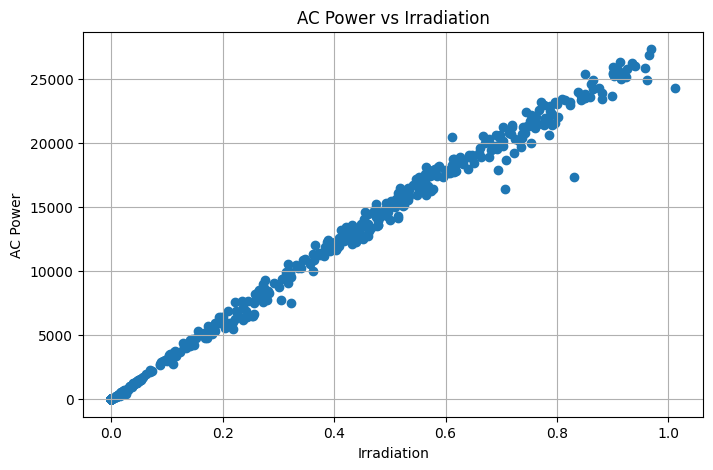

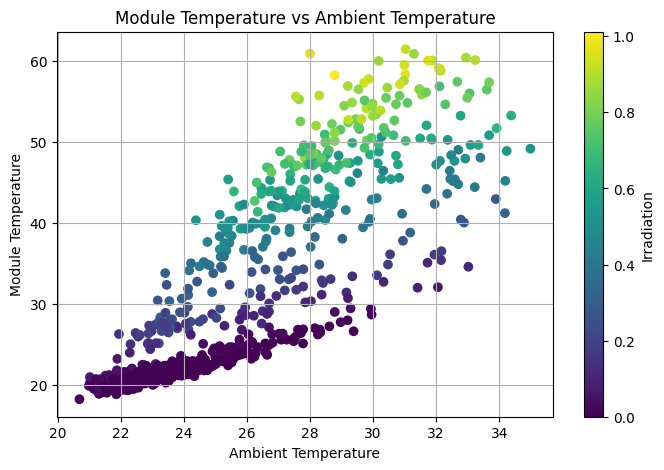

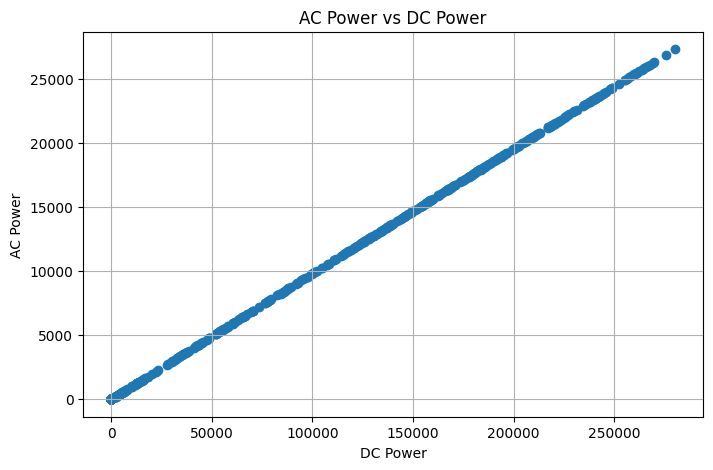

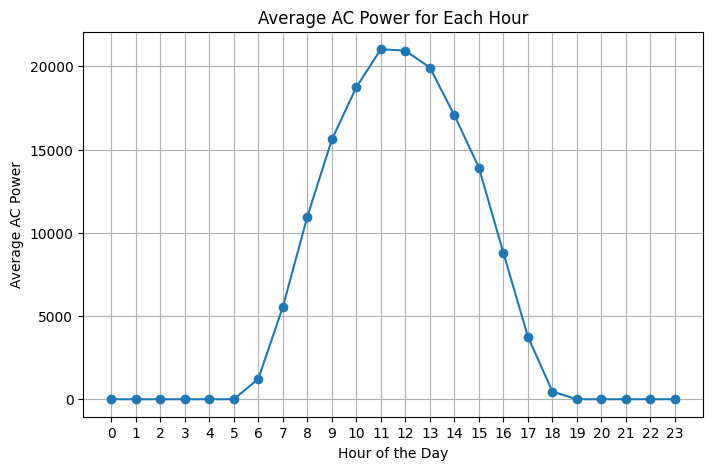

Open-Meteo URL:
https://archive-api.open-meteo.com/v1/archive?latitude=14.82&longitude=78.28&start_date=2020-05-15&end_date=2020-06-17&timezone=Asia%2FKolkata&hourly=shortwave_radiation,temperature_2m,cloud_cover

Status code: 200

Weather data received successfully.
             datetime  swradiation  temp2m  cloudcover
0 2020-05-15 00:00:00          0.0    29.5          13
1 2020-05-15 01:00:00          0.0    28.7           8
2 2020-05-15 02:00:00          0.0    28.0          16
3 2020-05-15 03:00:00          0.0    27.5          39
4 2020-05-15 04:00:00          0.0    27.0          36
File saved successfully
             datetime  ac power  dc power  ambient temp  module temp  \
0 2020-05-15 00:00:00       0.0       0.0     25.012697    22.643083   
1 2020-05-15 01:00:00       0.0       0.0     24.667328    22.411960   
2 2020-05-15 02:00:00       0.0       0.0     24.986837    23.512072   
3 2020-05-15 03:00:00       0.0       0.0     24.954589    24.126433   
4 2020-05-15 04:00

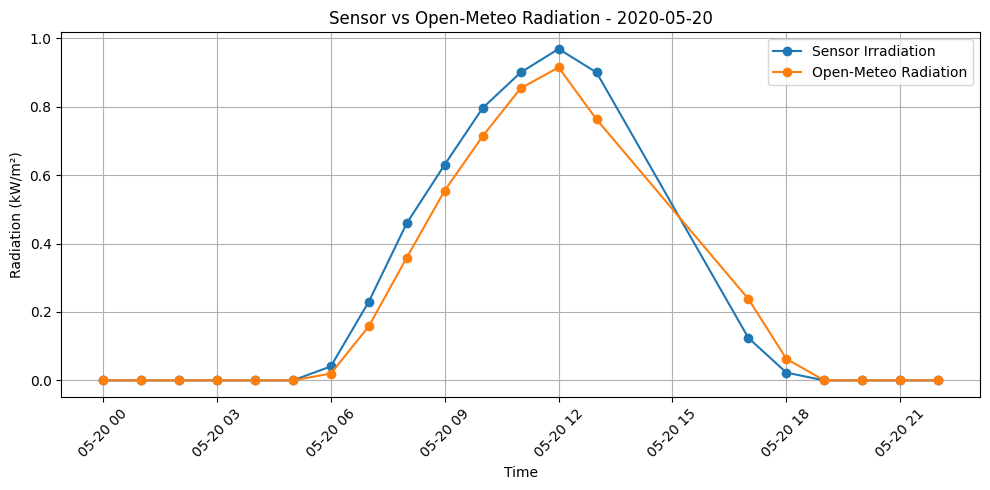


Date: 2020-05-25
Sensor irradiation peak: 12:00 Hour
Open-Meteo radiation peak: 12:00 Hour
Peak hour difference: 0 hour(s)


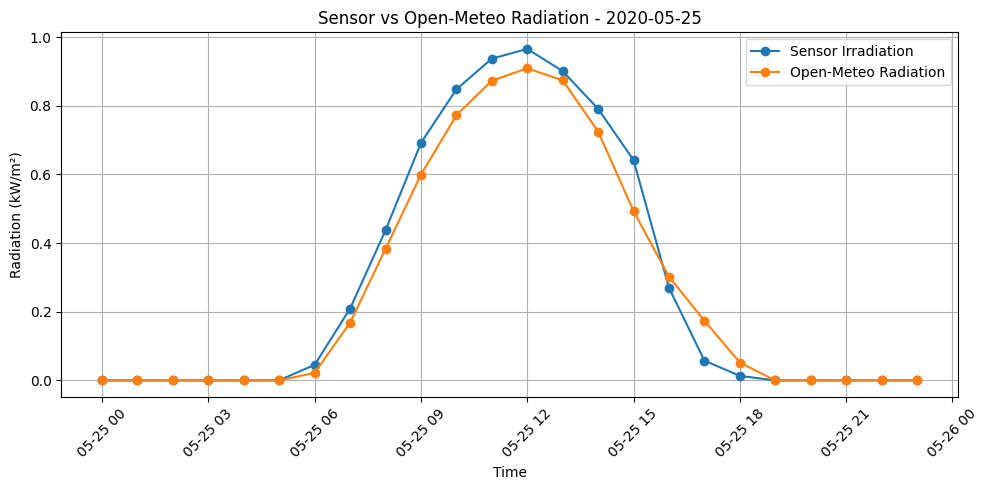


Date: 2020-05-30
Sensor irradiation peak: 12:00 Hour
Open-Meteo radiation peak: 12:00 Hour
Peak hour difference: 0 hour(s)


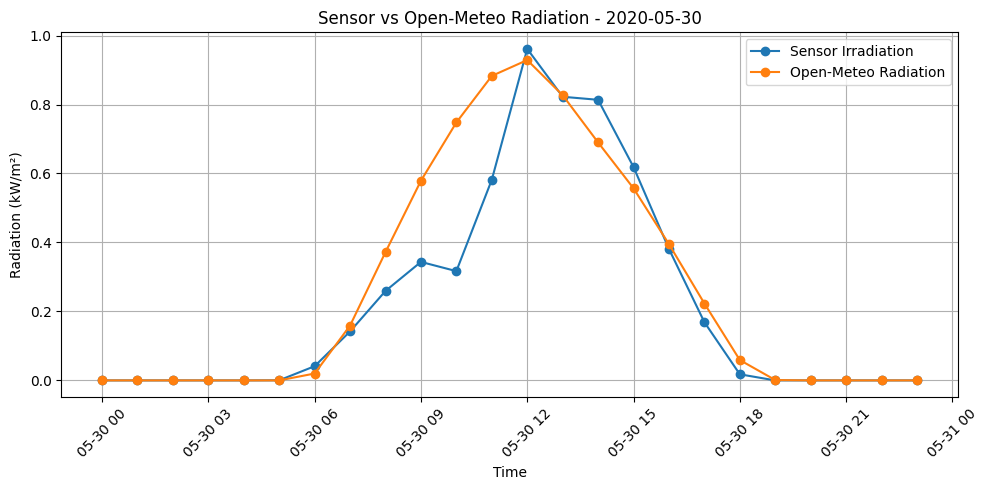

In [85]:
generated_df = pd.read_csv('Plant_1_Generation_Data.csv')
weather_df = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

print("Generation DATE_TIME:")
print(generated_df["DATE_TIME"].head())

print("\nWeather DATE_TIME:")
print(weather_df["DATE_TIME"].head())
generated_df["DATE_TIME"] = pd.to_datetime(
    generated_df["DATE_TIME"],
    format="%d-%m-%Y %H:%M"
)

# Weather file format:
# YYYY-MM-DD HH:MM:SS
weather_df["DATE_TIME"] = pd.to_datetime(
    weather_df["DATE_TIME"],
    format="%Y-%m-%d %H:%M:%S"
)


# Step 3: Print first and last timestamp

print("\nGeneration Data:")
print("First timestamp:", generated_df["DATE_TIME"].min())
print("Last timestamp :", generated_df["DATE_TIME"].max())

print("\nWeather Data:")
print("First timestamp:", weather_df["DATE_TIME"].min())
print("Last timestamp :", weather_df["DATE_TIME"].max())

# Sum AC and DC power for all inverters at each time

plant_power = generated_df.groupby("DATE_TIME")[["AC_POWER", "DC_POWER"]].sum()

plant_power = plant_power.reset_index()

print(plant_power.head())

# maximum power

max_power = plant_power.loc[
    plant_power[["AC_POWER", "DC_POWER"]].sum(axis=1).idxmax()
]

print("DATE_TIME:", max_power["DATE_TIME"])
print("Maximum AC Power:", max_power["AC_POWER"])
print("Maximum DC Power:", max_power["DC_POWER"])

# Merge plant power with weather data

merged_df = pd.merge(
    plant_power,
    weather_df,
    on="DATE_TIME",
    how="outer",
    indicator=True
)

# Count timestamps that are present in only one file

print("\nTimestamps only in plant power:",
      (merged_df["_merge"] == "left_only").sum())

print("Timestamps only in weather data:",
      (merged_df["_merge"] == "right_only").sum())

print("Total timestamps only in one file:",
      (merged_df["_merge"] != "both").sum())

# Hourly means

merged_df = merged_df.set_index("DATE_TIME")

hourly_df = merged_df[
    ["AC_POWER", "DC_POWER", "AMBIENT_TEMPERATURE",
     "MODULE_TEMPERATURE", "IRRADIATION"]
].resample("1h").mean()

hourly_df = hourly_df.reset_index()

hourly_df.columns = [
    "datetime",
    "ac power",
    "dc power",
    "ambient temp",
    "module temp",
    "irradiation"
]

print(hourly_df.head())
print(hourly_df.shape)

import os
os.makedirs("data", exist_ok=True)

hourly_df.to_csv("data/plant1 hourly.csv", index=False)

print("File saved successfully")
# Number of hourly rows
print("Number of hourly rows:", len(hourly_df))

# Number of rows with missing values
missing_rows = hourly_df.isnull().any(axis=1).sum()
print("Rows with missing values:", missing_rows)

# Check missing values in each column
print("\nMissing values in each column:")
print(hourly_df.isnull().sum())
hourly_df = hourly_df.dropna()

print("Rows after removing missing values:", len(hourly_df))
print("Missing values:", hourly_df.isnull().any(axis=1).sum())
hourly_df.to_csv("data/plant1 hourly.csv", index=False)

# Report:
# Number of hourly rows: 816
# Rows with missing values: 20
# Handling: The 20 rows containing missing values were removed using dropna()

#Task2

# 1)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    hourly_df["irradiation"],
    hourly_df["ac power"]
)

plt.xlabel("Irradiation")
plt.ylabel("AC Power")
plt.title("AC Power vs Irradiation")
plt.grid(True)

plt.show()
# Results
# Observation: The data agrees with this because AC power increases
# almost linearly as irradiation increases.
# Most points are close to the main trend, but a few points are
# slightly away from it, especially at higher irradiation.

# 2)
plt.figure(figsize=(8, 5))

plt.scatter(
    hourly_df["ambient temp"],
    hourly_df["module temp"],
    c=hourly_df["irradiation"],
    cmap="viridis"
)

plt.xlabel("Ambient Temperature")
plt.ylabel("Module Temperature")
plt.title("Module Temperature vs Ambient Temperature")
plt.colorbar(label="Irradiation")
plt.grid(True)

plt.show()
# Results
# The data agrees with this because module temperature generally
# increases as ambient temperature increases.

# The higher irradiation points have higher module temperatures,
# showing that sunlight also heats the PV modules.

# There is some spread in the points, so module temperature is
# affected by both ambient temperature and irradiation.

# 3)
plt.figure(figsize=(8, 5))

plt.scatter(
    hourly_df["dc power"],
    hourly_df["ac power"]
)

plt.xlabel("DC Power")
plt.ylabel("AC Power")
plt.title("AC Power vs DC Power")
plt.grid(True)

plt.show()
# Results
# Observation: The data shows a strong positive relationship between
# DC power and AC power, with the points following a nearly straight line.
# AC power is generally lower than DC power because some power is
# lost during the DC-to-AC conversion in the inverter.

# 4)
hourly_df["hour"] = hourly_df["datetime"].dt.hour
average_ac = hourly_df.groupby("hour")["ac power"].mean()
plt.figure(figsize=(8, 5))
plt.plot(average_ac.index, average_ac.values, marker="o")
plt.xlabel("Hour of the Day")
plt.ylabel("Average AC Power")
plt.title("Average AC Power for Each Hour")
plt.xticks(range(24))
plt.grid(True)

plt.show()
# Result
# During the day, AC power should increase after sunrise, reach
# a maximum around the middle of the day, and then decrease.

# Observation: The data should show a similar daily pattern, with
# low power at night and higher power during daylight hours.

# Task 3
# 3.1 Get historical weather data from Open-Meteo

import requests

# Task 3
# 3.1 Get historical weather data from Open-Meteo

import requests

latitude = 14.82
longitude = 78.28

# Build the Open-Meteo URL
url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={latitude}"
    f"&longitude={longitude}"
    "&start_date=2020-05-15"
    "&end_date=2020-06-17"
    "&timezone=Asia%2FKolkata"
    "&hourly=shortwave_radiation,temperature_2m,cloud_cover"
)

print("Open-Meteo URL:")
print(url)

# Send request to the API
response = requests.get(url)

print("\nStatus code:", response.status_code)

# Convert response to JSON
weather_data = response.json()

print("\nWeather data received successfully.")

# 2)

import pandas as pd
import os

# Get hourly data from the API response
openmeteo_df = pd.DataFrame(weather_data["hourly"])

# Rename the columns
openmeteo_df.columns = [
    "datetime",
    "swradiation",
    "temp2m",
    "cloudcover"
]

# Convert datetime column
openmeteo_df["datetime"] = pd.to_datetime(openmeteo_df["datetime"])

# Save the file
os.makedirs("data", exist_ok=True)

openmeteo_df.to_csv("data/plant1openmeteo.csv", index=False)

print(openmeteo_df.head())
print("File saved successfully")

# 3)

# Read both files
plant_df = pd.read_csv("data/plant1 hourly.csv")
openmeteo_df = pd.read_csv("data/plant1openmeteo.csv")

# Convert datetime
plant_df["datetime"] = pd.to_datetime(plant_df["datetime"])
openmeteo_df["datetime"] = pd.to_datetime(openmeteo_df["datetime"])

# Convert Open-Meteo radiation from W/m2 to kW/m2
openmeteo_df["swradiation"] = openmeteo_df["swradiation"] / 1000

# Merge both datasets
merged_weather = pd.merge(
    plant_df,
    openmeteo_df,
    on="datetime",
    how="inner"
)

print(merged_weather.head())
print("\nShape:", merged_weather.shape)

# 4)
# Compare sensor irradiation with Open-Meteo radiation

import matplotlib.pyplot as plt
import pandas as pd

# Make sure datetime is in datetime format
merged_weather["datetime"] = pd.to_datetime(
    merged_weather["datetime"]
)

# Select three days
three_days = [
    "2020-05-20",
    "2020-05-25",
    "2020-05-30"
]

for day in three_days:

    # Select one day
    day_data = merged_weather[
        merged_weather["datetime"].dt.strftime("%Y-%m-%d") == day
    ].copy()

    # Find peak of sensor irradiation
    sensor_peak = day_data.loc[
        day_data["irradiation"].idxmax()
    ]

    # Find peak of Open-Meteo radiation
    openmeteo_peak = day_data.loc[
        day_data["swradiation"].idxmax()
    ]

    print("\nDate:", day)

    print(
        "Sensor irradiation peak:",
        sensor_peak["datetime"].strftime("%H:%M"),
        "Hour"
    )

    print(
        "Open-Meteo radiation peak:",
        openmeteo_peak["datetime"].strftime("%H:%M"),
        "Hour"
    )

    # Difference in peak hours
    sensor_hour = sensor_peak["datetime"].hour
    openmeteo_hour = openmeteo_peak["datetime"].hour

    difference = abs(sensor_hour - openmeteo_hour)

    print("Peak hour difference:", difference, "hour(s)")

    # Plot both curves
    plt.figure(figsize=(10, 5))

    plt.plot(
        day_data["datetime"],
        day_data["irradiation"],
        marker="o",
        label="Sensor Irradiation"
    )

    plt.plot(
        day_data["datetime"],
        day_data["swradiation"],
        marker="o",
        label="Open-Meteo Radiation"
    )

    plt.xlabel("Time")
    plt.ylabel("Radiation (kW/m²)")
    plt.title("Sensor vs Open-Meteo Radiation - " + day)

    plt.xticks(rotation=45)

    plt.legend()
    plt.grid(True)

    plt.tight_layout()

    plt.show()

Training rows: 628
Testing rows : 168
Set A training shape: (628, 5)
Set A testing shape : (168, 5)
Set B training shape: (628, 5)
Set B testing shape : (168, 5)
Set A scaling completed.
Set B scaling completed.
Set A training means:
[ 1.96587262e-16  4.52574991e-17  4.52574991e-16 -4.52574991e-17
  5.33897060e-17]

Set A training standard deviations:
[1. 1. 1. 1. 1.]

Set B training means:
[ 1.07486560e-16  0.00000000e+00  6.78862486e-17 -4.52574991e-17
  5.33897060e-17]

Set B training standard deviations:
[1. 1. 1. 1. 1.]
Set A training shape: (628, 6)
Set A testing shape : (168, 6)
Set B training shape: (628, 6)
Set B testing shape : (168, 6)
First row of Set A:
[ 1.         -0.78944613 -0.71986445 -0.23538933  0.01181139  1.44337225]

First row of Set B:
[ 1.         -0.79817809 -0.87121264 -1.63111485  0.01181139  1.44337225]
Theta shape: (6,)
First 5 predictions: [0. 0. 0. 0. 0.]
Initial cost: 38080745933.978874
Theta for Set A:
[6883.41663981 8258.29649425  -25.54499228  -15.92

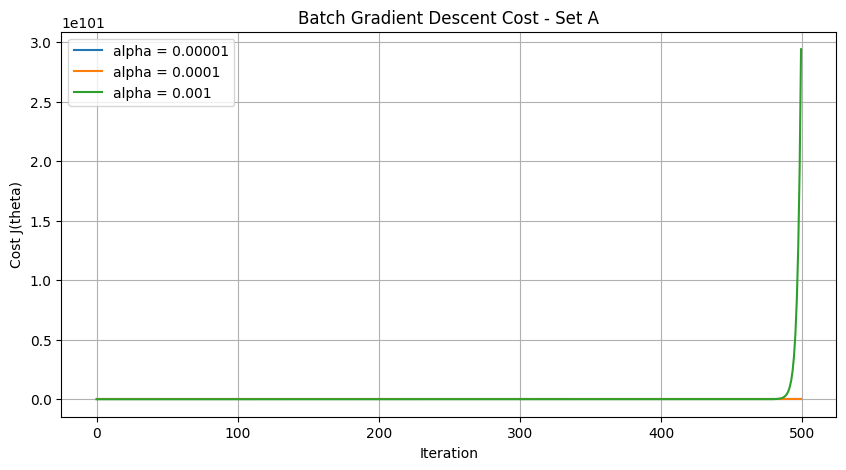

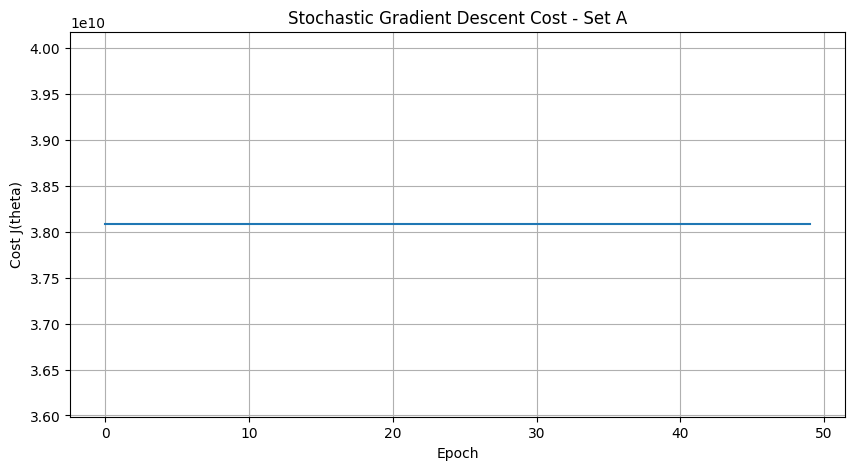

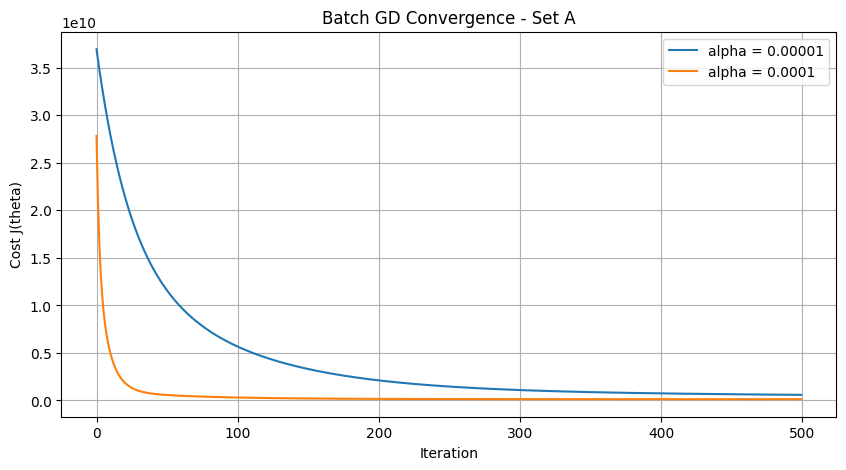

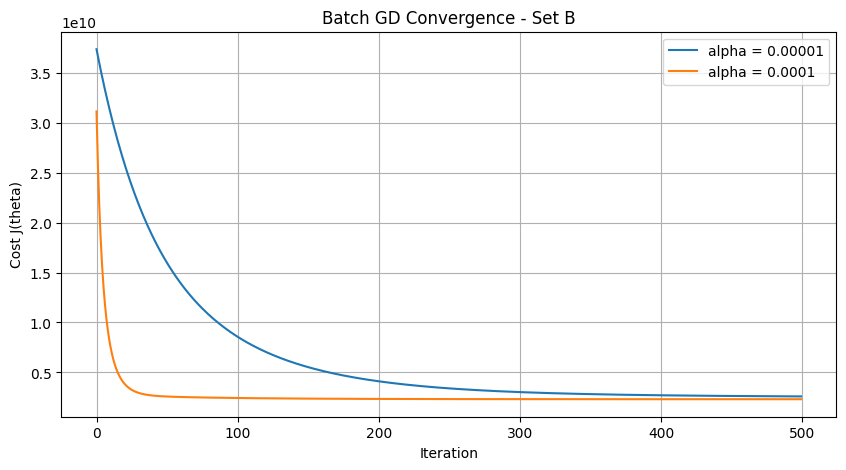

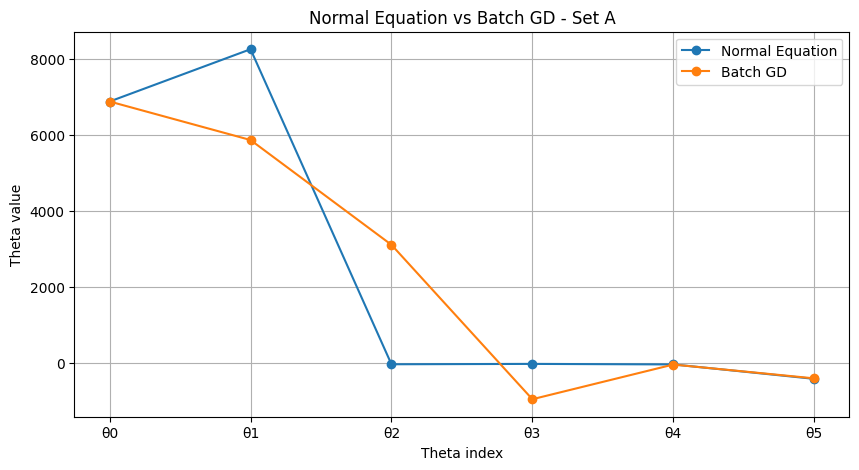

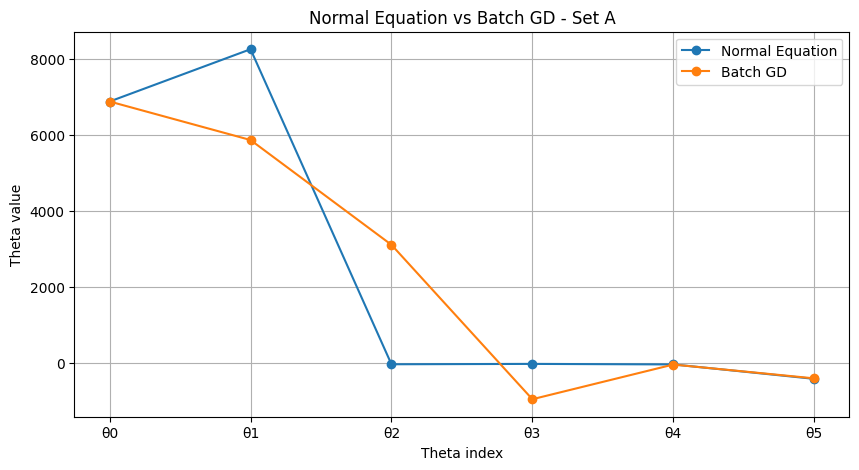

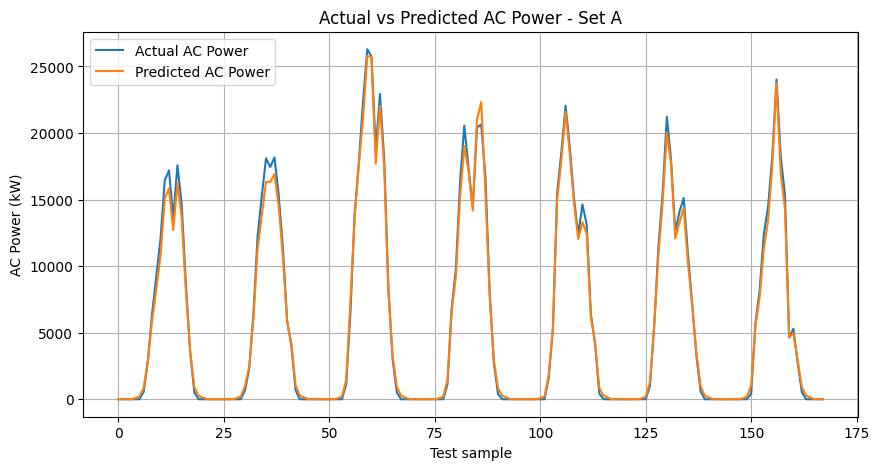

In [60]:


    # Task 4
    # 1)
# Prepare training and testing data

import numpy as np
import pandas as pd

# Make sure datetime is in datetime format
merged_weather["datetime"] = pd.to_datetime(
    merged_weather["datetime"]
)

# Add hour of the day
merged_weather["hour"] = merged_weather["datetime"].dt.hour

# Add time features
merged_weather["sin_hour"] = np.sin(
    2 * np.pi * merged_weather["hour"] / 24
)

merged_weather["cos_hour"] = np.cos(
    2 * np.pi * merged_weather["hour"] / 24
)

# Training data: 15 May to 10 June
train_df = merged_weather[
    (merged_weather["datetime"] >= "2020-05-15") &
    (merged_weather["datetime"] < "2020-06-11")
].copy()

# Testing data: 11 June to 17 June
test_df = merged_weather[
    (merged_weather["datetime"] >= "2020-06-11") &
    (merged_weather["datetime"] < "2020-06-18")
].copy()

print("Training rows:", len(train_df))
print("Testing rows :", len(test_df))

# Set A features
# On-site sensor data

features_A = [
    "irradiation",
    "module temp",
    "ambient temp",
    "sin_hour",
    "cos_hour"
]

# Set B features
# Open-Meteo public weather data

features_B = [
    "swradiation",
    "temp2m",
    "cloudcover",
    "sin_hour",
    "cos_hour"
]

# Target
y_train = train_df["ac power"].to_numpy()
y_test = test_df["ac power"].to_numpy()

# Feature data
X_train_A_raw = train_df[features_A].to_numpy()
X_test_A_raw = test_df[features_A].to_numpy()

X_train_B_raw = train_df[features_B].to_numpy()
X_test_B_raw = test_df[features_B].to_numpy()

print("Set A training shape:", X_train_A_raw.shape)
print("Set A testing shape :", X_test_A_raw.shape)

print("Set B training shape:", X_train_B_raw.shape)
print("Set B testing shape :", X_test_B_raw.shape)

# Calculate mean and standard deviation from training data only

mean_A = np.mean(X_train_A_raw, axis=0)
std_A = np.std(X_train_A_raw, axis=0)

mean_B = np.mean(X_train_B_raw, axis=0)
std_B = np.std(X_train_B_raw, axis=0)

# Scale Set A
X_train_A_scaled = (
    X_train_A_raw - mean_A
) / std_A

X_test_A_scaled = (
    X_test_A_raw - mean_A
) / std_A

# Scale Set B
X_train_B_scaled = (
    X_train_B_raw - mean_B
) / std_B

X_test_B_scaled = (
    X_test_B_raw - mean_B
) / std_B

print("Set A scaling completed.")
print("Set B scaling completed.")

print("Set A training means:")
print(np.mean(X_train_A_scaled, axis=0))

print("\nSet A training standard deviations:")
print(np.std(X_train_A_scaled, axis=0))

print("\nSet B training means:")
print(np.mean(X_train_B_scaled, axis=0))

print("\nSet B training standard deviations:")
print(np.std(X_train_B_scaled, axis=0))

# 2)
# Add intercept column x0 = 1

# Set A
X_train_A = np.column_stack((
    np.ones(len(X_train_A_scaled)),
    X_train_A_scaled
))

X_test_A = np.column_stack((
    np.ones(len(X_test_A_scaled)),
    X_test_A_scaled
))

# Set B
X_train_B = np.column_stack((
    np.ones(len(X_train_B_scaled)),
    X_train_B_scaled
))

X_test_B = np.column_stack((
    np.ones(len(X_test_B_scaled)),
    X_test_B_scaled
))

print("Set A training shape:", X_train_A.shape)
print("Set A testing shape :", X_test_A.shape)

print("Set B training shape:", X_train_B.shape)
print("Set B testing shape :", X_test_B.shape)

print("First row of Set A:")
print(X_train_A[0])

print("\nFirst row of Set B:")
print(X_train_B[0])

# 3)


hypothesis = lambda X, theta: np.dot(X, theta)

cost = lambda X, y, theta: 0.5 * np.sum(
    (hypothesis(X, theta) - y) ** 2
)
theta_test = np.zeros(X_train_A.shape[1])

print("Theta shape:", theta_test.shape)
print("First 5 predictions:", hypothesis(X_train_A, theta_test)[:5])
print("Initial cost:", cost(X_train_A, y_train, theta_test))

# 4)
# Normal Equation

fit_normal = lambda X, y: np.dot(
    np.linalg.inv(np.dot(X.T, X)),
    np.dot(X.T, y)
)
theta_normal_A = fit_normal(X_train_A, y_train)

print("Theta for Set A:")
print(theta_normal_A)
theta_normal_B = fit_normal(X_train_B, y_train)

print("\nTheta for Set B:")
print(theta_normal_B)

# 5
# Batch Gradient Descent

alpha = 0.0001
n_iters = 500

theta_batch_A = np.zeros(X_train_A.shape[1])
cost_history_A = []

theta_batch_A = np.array(theta_batch_A)

theta_batch_A = (
    theta_batch_A
    + alpha * np.dot(X_train_A.T, y_train - np.dot(X_train_A, theta_batch_A))
)

cost_history_A.append(
    0.5 * np.sum(
        (np.dot(X_train_A, theta_batch_A) - y_train) ** 2
    )
)

print("Theta after 1 iteration:")
print(theta_batch_A)

print("Cost after 1 iteration:")
print(cost_history_A[-1])

# 6
# Stochastic Gradient Descent

alpha = 0.0001
n_epochs = 50

theta_sgd_A = np.zeros(X_train_A.shape[1])
cost_history_sgd_A = []

epoch = 0

while epoch < n_epochs: theta_sgd_A = np.array([theta_sgd_A + alpha * (y_train[i] - np.dot(X_train_A[i], theta_sgd_A)) * X_train_A[i] for i in range(len(y_train))])[-1]; cost_history_sgd_A.append(0.5 * np.sum((np.dot(X_train_A, theta_sgd_A) - y_train) ** 2)); epoch = epoch + 1

print("SGD Theta for Set A:")
print(theta_sgd_A)

print("Initial cost:", cost_history_sgd_A[0])
print("Final cost:", cost_history_sgd_A[-1])

# 7
# Batch GD with alpha = 0.00001

alpha = 0.00001
n_iters = 500

theta_batch_A_1e5 = np.zeros(X_train_A.shape[1])
cost_batch_A_1e5 = []

iteration = 0

while iteration < n_iters: predictions = np.dot(X_train_A, theta_batch_A_1e5); errors = y_train - predictions; gradient = np.dot(X_train_A.T, errors); theta_batch_A_1e5 = theta_batch_A_1e5 + alpha * gradient; current_cost = 0.5 * np.sum((np.dot(X_train_A, theta_batch_A_1e5) - y_train) ** 2); cost_batch_A_1e5.append(current_cost); iteration = iteration + 1

print("Alpha:", alpha)
print("Theta:", theta_batch_A_1e5)
print("Final cost:", cost_batch_A_1e5[-1])

# Batch GD with alpha = 0.0001

alpha = 0.0001
n_iters = 500

theta_batch_A_1e4 = np.zeros(X_train_A.shape[1])
cost_batch_A_1e4 = []

iteration = 0

while iteration < n_iters: predictions = np.dot(X_train_A, theta_batch_A_1e4); errors = y_train - predictions; gradient = np.dot(X_train_A.T, errors); theta_batch_A_1e4 = theta_batch_A_1e4 + alpha * gradient; current_cost = 0.5 * np.sum((np.dot(X_train_A, theta_batch_A_1e4) - y_train) ** 2); cost_batch_A_1e4.append(current_cost); iteration = iteration + 1

print("Alpha:", alpha)
print("Theta:", theta_batch_A_1e4)
print("Final cost:", cost_batch_A_1e4[-1])


# Batch GD with alpha = 0.001

alpha = 0.001
n_iters = 500

theta_batch_A_1e3 = np.zeros(X_train_A.shape[1])
cost_batch_A_1e3 = []

iteration = 0

while iteration < n_iters: predictions = np.dot(X_train_A, theta_batch_A_1e3); errors = y_train - predictions; gradient = np.dot(X_train_A.T, errors); theta_batch_A_1e3 = theta_batch_A_1e3 + alpha * gradient; current_cost = 0.5 * np.sum((np.dot(X_train_A, theta_batch_A_1e3) - y_train) ** 2); cost_batch_A_1e3.append(current_cost); iteration = iteration + 1

print("Alpha:", alpha)
print("Theta:", theta_batch_A_1e3)
print("Final cost:", cost_batch_A_1e3[-1])

# 8
# Normal Equation for Set B

theta_normal_B = np.dot(
    np.linalg.inv(np.dot(X_train_B.T, X_train_B)),
    np.dot(X_train_B.T, y_train)
)

print("Normal Equation - Set B:")
print(theta_normal_B)

# Batch GD - Set B, alpha = 0.00001

alpha = 0.00001
n_iters = 500

theta_batch_B_1e5 = np.zeros(X_train_B.shape[1])
cost_batch_B_1e5 = []

iteration = 0

while iteration < n_iters: predictions = np.dot(X_train_B, theta_batch_B_1e5); errors = y_train - predictions; gradient = np.dot(X_train_B.T, errors); theta_batch_B_1e5 = theta_batch_B_1e5 + alpha * gradient; current_cost = 0.5 * np.sum((np.dot(X_train_B, theta_batch_B_1e5) - y_train) ** 2); cost_batch_B_1e5.append(current_cost); iteration = iteration + 1

print("Alpha:", alpha)
print("Theta:", theta_batch_B_1e5)
print("Final cost:", cost_batch_B_1e5[-1])

# Batch GD - Set B, alpha = 0.0001

alpha = 0.0001
n_iters = 500

theta_batch_B_1e4 = np.zeros(X_train_B.shape[1])
cost_batch_B_1e4 = []

iteration = 0

while iteration < n_iters: predictions = np.dot(X_train_B, theta_batch_B_1e4); errors = y_train - predictions; gradient = np.dot(X_train_B.T, errors); theta_batch_B_1e4 = theta_batch_B_1e4 + alpha * gradient; current_cost = 0.5 * np.sum((np.dot(X_train_B, theta_batch_B_1e4) - y_train) ** 2); cost_batch_B_1e4.append(current_cost); iteration = iteration + 1

print("Alpha:", alpha)
print("Theta:", theta_batch_B_1e4)
print("Final cost:", cost_batch_B_1e4[-1])

# Batch GD - Set B, alpha = 0.001

alpha = 0.001
n_iters = 500

theta_batch_B_1e3 = np.zeros(X_train_B.shape[1])
cost_batch_B_1e3 = []

iteration = 0

while iteration < n_iters: predictions = np.dot(X_train_B, theta_batch_B_1e3); errors = y_train - predictions; gradient = np.dot(X_train_B.T, errors); theta_batch_B_1e3 = theta_batch_B_1e3 + alpha * gradient; current_cost = 0.5 * np.sum((np.dot(X_train_B, theta_batch_B_1e3) - y_train) ** 2); cost_batch_B_1e3.append(current_cost); iteration = iteration + 1

print("Alpha:", alpha)
print("Theta:", theta_batch_B_1e3)
print("Final cost:", cost_batch_B_1e3[-1])

# 9
# Compare Batch GD with Normal Equation - Set A

difference_A = np.abs(theta_batch_A_1e4 - theta_normal_A)

print("Normal Equation Theta - Set A:")
print(theta_normal_A)

print("\nBatch GD Theta - Set A:")
print(theta_batch_A_1e4)

print("\nAbsolute difference:")
print(difference_A)

print("\nMaximum difference:")
print(np.max(difference_A))

# Compare Batch GD with Normal Equation - Set B

difference_B = np.abs(theta_batch_B_1e4 - theta_normal_B)

print("Normal Equation Theta - Set B:")
print(theta_normal_B)

print("\nBatch GD Theta - Set B:")
print(theta_batch_B_1e4)

print("\nAbsolute difference:")
print(difference_B)

print("\nMaximum difference:")
print(np.max(difference_B))

# 10
# Predict AC power on the test set

# Set A - Normal Equation
pred_A_normal = np.dot(X_test_A, theta_normal_A)

# Set A - Batch GD
pred_A_batch = np.dot(X_test_A, theta_batch_A_1e4)

# Set B - Normal Equation
pred_B_normal = np.dot(X_test_B, theta_normal_B)

# Set B - Batch GD
pred_B_batch = np.dot(X_test_B, theta_batch_B_1e4)


# Clip negative predictions to zero
pred_A_normal = np.maximum(pred_A_normal, 0)
pred_A_batch = np.maximum(pred_A_batch, 0)
pred_B_normal = np.maximum(pred_B_normal, 0)
pred_B_batch = np.maximum(pred_B_batch, 0)


print("First 5 predictions - Set A Normal Equation:")
print(pred_A_normal[:5])

print("\nFirst 5 predictions - Set A Batch GD:")
print(pred_A_batch[:5])

print("\nFirst 5 predictions - Set B Normal Equation:")
print(pred_B_normal[:5])

print("\nFirst 5 predictions - Set B Batch GD:")
print(pred_B_batch[:5])

# 4.5
# Batch GD cost curves for Set A

plt.figure(figsize=(10, 5))

plt.plot(cost_batch_A_1e5, label="alpha = 0.00001")
plt.plot(cost_batch_A_1e4, label="alpha = 0.0001")
plt.plot(cost_batch_A_1e3, label="alpha = 0.001")

plt.xlabel("Iteration")
plt.ylabel("Cost J(theta)")
plt.title("Batch Gradient Descent Cost - Set A")
plt.legend()
plt.grid(True)
plt.show()

# 4.6
# SGD cost curve for Set A

plt.figure(figsize=(10, 5))

plt.plot(cost_history_sgd_A)

plt.xlabel("Epoch")
plt.ylabel("Cost J(theta)")
plt.title("Stochastic Gradient Descent Cost - Set A")
plt.grid(True)
plt.show()


# 4.7

plt.figure(figsize=(10, 5))

plt.plot(cost_batch_A_1e5, label="alpha = 0.00001")
plt.plot(cost_batch_A_1e4, label="alpha = 0.0001")

plt.xlabel("Iteration")
plt.ylabel("Cost J(theta)")
plt.title("Batch GD Convergence - Set A")
plt.legend()
plt.grid(True)
plt.show()

# 4.8

plt.figure(figsize=(10, 5))

plt.plot(cost_batch_B_1e5, label="alpha = 0.00001")
plt.plot(cost_batch_B_1e4, label="alpha = 0.0001")

plt.xlabel("Iteration")
plt.ylabel("Cost J(theta)")
plt.title("Batch GD Convergence - Set B")
plt.legend()
plt.grid(True)
plt.show()

# 4.9
# Normal Equation vs Batch GD - Set A

x = np.arange(6)

plt.figure(figsize=(10, 5))

plt.plot(x, theta_normal_A, marker="o", label="Normal Equation")
plt.plot(x, theta_batch_A_1e4, marker="o", label="Batch GD")

plt.xlabel("Theta index")
plt.ylabel("Theta value")
plt.title("Normal Equation vs Batch GD - Set A")
plt.xticks(x, ["θ0", "θ1", "θ2", "θ3", "θ4", "θ5"])
plt.legend()
plt.grid(True)
plt.show()

# 4.9
# Normal Equation vs Batch GD - Set A

x = np.arange(6)

plt.figure(figsize=(10, 5))

plt.plot(x, theta_normal_A, marker="o", label="Normal Equation")
plt.plot(x, theta_batch_A_1e4, marker="o", label="Batch GD")

plt.xlabel("Theta index")
plt.ylabel("Theta value")
plt.title("Normal Equation vs Batch GD - Set A")
plt.xticks(x, ["θ0", "θ1", "θ2", "θ3", "θ4", "θ5"])
plt.legend()
plt.grid(True)
plt.show()

# 4.10
# Actual AC Power vs Predicted AC Power - Set A

plt.figure(figsize=(10, 5))

plt.plot(y_test, label="Actual AC Power")
plt.plot(pred_A_normal, label="Predicted AC Power")

plt.xlabel("Test sample")
plt.ylabel("AC Power (kW)")
plt.title("Actual vs Predicted AC Power - Set A")
plt.legend()
plt.grid(True)
plt.show()

Theta values for Set A:
[6883.41663981 8258.29649425  -25.54499228  -15.929397    -29.8325702
 -408.77253693]

Theta values:
Theta 0 = 6883.416639809079
Theta 1 = 8258.296494245244
Theta 2 = -25.54499227658016
Theta 3 = -15.92939700167517
Theta 4 = -29.832570199995644
Theta 5 = -408.77253693454986
Largest weight: Irradiation
Weight value: 8258.296494245244

Set A RMSE: 553.3193624127988 kW
Set B RMSE: 2626.129230218626 kW
Set A RMSE: 553.3193624127988 kW
Set B RMSE: 2626.129230218626 kW
RMSE difference: 2072.8098678058273 kW
Percentage difference: 374.6136514665154 %
Normal Equation Theta - Set A:
[6883.41663981 8258.29649425  -25.54499228  -15.929397    -29.8325702
 -408.77253693]

Batch GD Theta - Set A:
[6883.41663981 5870.9223526  3115.73464594 -944.56268579  -32.67211094
 -396.58961353]

Absolute difference:
[5.63886715e-11 2.38737414e+03 3.14127964e+03 9.28633289e+02
 2.83954074e+00 1.21829234e+01]

Maximum difference:
3141.279638216904
Normal Equation Theta - Set B:
[ 6883.41663

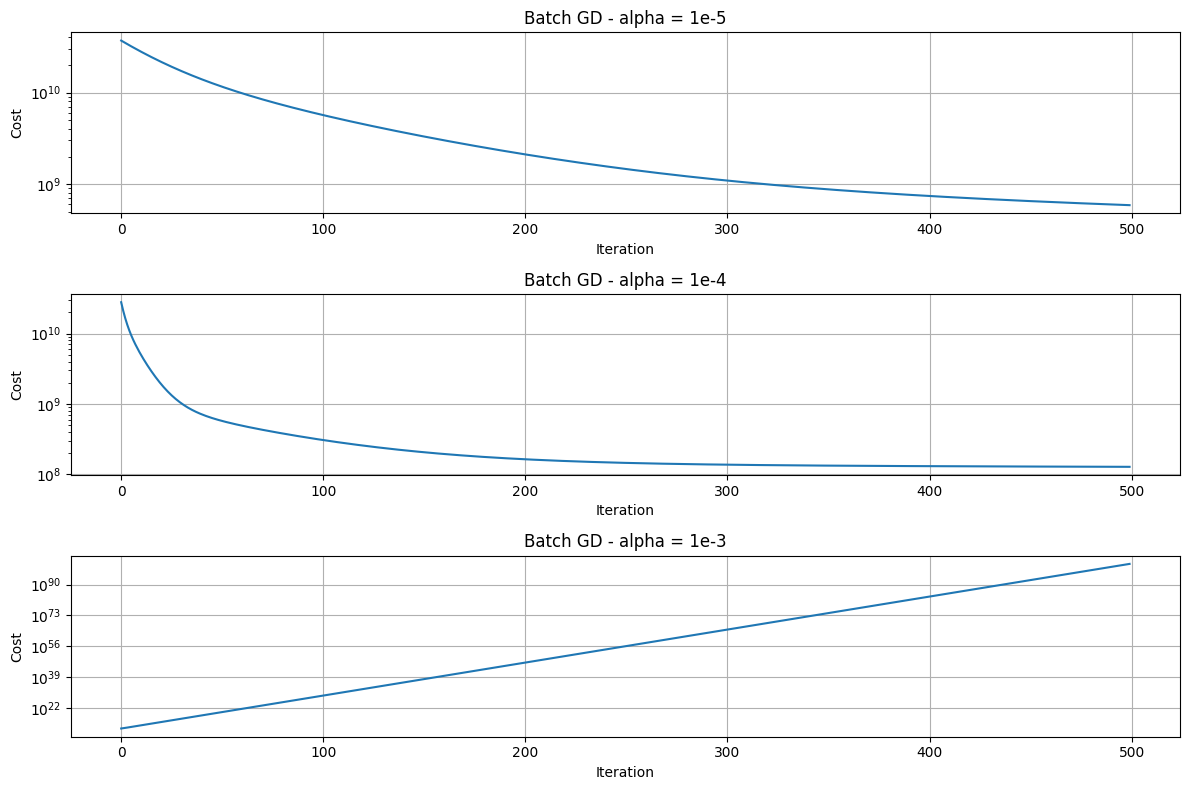

Final cost for alpha = 1e-5: 588252123.5779248
Final cost for alpha = 1e-4: 127581018.65338506
Final cost for alpha = 1e-3: 2.942234341837486e+101
SGD Theta for Set A:
[ 6590.53202451  3638.61752341  2828.30353931   651.08413117
   827.15130428 -1569.98599188]

Initial SGD cost: 28641344189.461853
Final SGD cost: 590275677.2721359


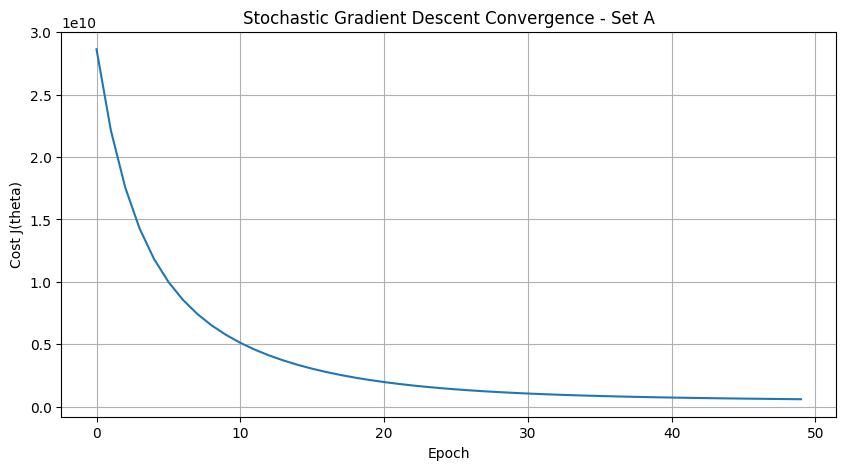

Normal Equation Theta - Set A:
[6883.41663981 8258.29649425  -25.54499228  -15.929397    -29.8325702
 -408.77253693]

SGD Theta - Set A:
[ 6590.53202451  3638.61752341  2828.30353931   651.08413117
   827.15130428 -1569.98599188]

Absolute difference:
[ 292.8846153  4619.67897083 2853.84853158  667.01352817  856.98387448
 1161.21345494]

Maximum difference:
4619.678970830386


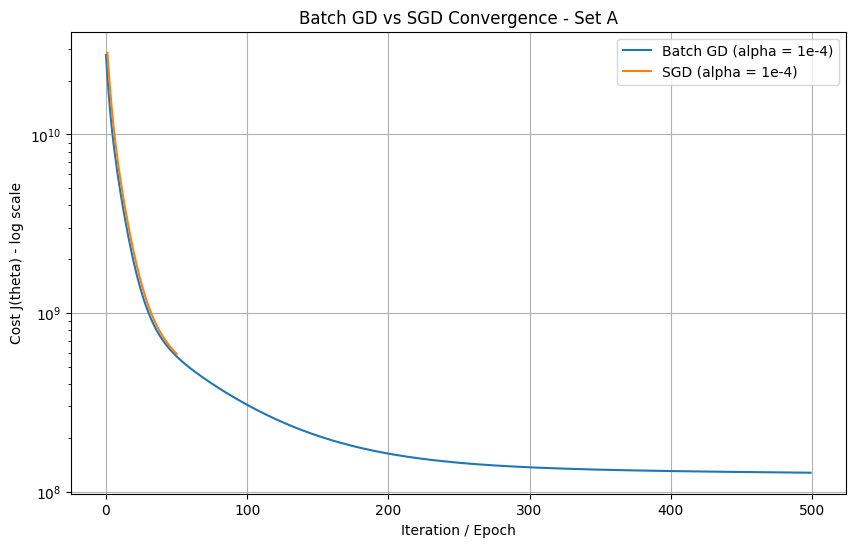

Batch GD (alpha = 1e-4)
Initial cost: 27824120227.21247
Final cost: 127581018.65338506

SGD (alpha = 1e-4)
Initial cost: 28641344189.461853
Final cost: 590275677.2721359

Cost reduction
Batch GD cost reduction: 27696539208.559086
SGD cost reduction: 28051068512.189716
Residual statistics by hour:
Hour 0 | Mean residual: 0.0 | Min: 0.0 | Max: 0.0
Hour 1 | Mean residual: 0.0 | Min: 0.0 | Max: 0.0
Hour 2 | Mean residual: 0.0 | Min: 0.0 | Max: 0.0
Hour 3 | Mean residual: 0.0 | Min: 0.0 | Max: 0.0
Hour 4 | Mean residual: -67.92118610352274 | Min: -73.29914925628464 | Max: -62.0581256700857
Hour 5 | Mean residual: -205.33525139459064 | Min: -210.63879829251005 | Max: -198.3031484352898
Hour 6 | Mean residual: -322.4235916469648 | Min: -604.3305632101449 | Max: -212.14888128863845
Hour 7 | Mean residual: -89.22817962056232 | Min: -844.9955490426591 | Max: 211.08165180245942
Hour 8 | Mean residual: 473.20508367012525 | Min: 202.78228582580596 | Max: 598.4922151913597
Hour 9 | Mean residual: 80

In [84]:
# Task 5
# 5.1
# Normal Equation theta for Set A

print("Theta values for Set A:")
print(theta_normal_A)

print("\nTheta values:")
for i in range(len(theta_normal_A)):
    print("Theta", i, "=", theta_normal_A[i])
# 5.2
# Find the feature with the largest absolute weight

feature_names = [
    "Intercept",
    "Irradiation",
    "Module Temperature",
    "Ambient Temperature",
    "Sin Hour",
    "Cos Hour"
]

weights = np.abs(theta_normal_A)

largest_index = np.argmax(weights)

print("Largest weight:", feature_names[largest_index])
print("Weight value:", theta_normal_A[largest_index])

# 5.3
# Calculate RMSE for Set A and Set B

rmse_A = np.sqrt(np.mean((y_test - pred_A_normal) ** 2))
rmse_B = np.sqrt(np.mean((y_test - pred_B_normal) ** 2))

print("\nSet A RMSE:", rmse_A, "kW")
print("Set B RMSE:", rmse_B, "kW")
# 5.3
# Calculate RMSE for Set A and Set B

rmse_A = np.sqrt(np.mean((y_test - pred_A_normal) ** 2))
rmse_B = np.sqrt(np.mean((y_test - pred_B_normal) ** 2))

print("Set A RMSE:", rmse_A, "kW")
print("Set B RMSE:", rmse_B, "kW")

difference = rmse_B - rmse_A
percentage = (difference / rmse_A) * 100

print("RMSE difference:", difference, "kW")
print("Percentage difference:", percentage, "%")

# 5.4
# Compare Normal Equation and Batch Gradient Descent for Set A

difference_A = np.abs(theta_normal_A - theta_batch_A_1e4)

print("Normal Equation Theta - Set A:")
print(theta_normal_A)

print("\nBatch GD Theta - Set A:")
print(theta_batch_A_1e4)

print("\nAbsolute difference:")
print(difference_A)

print("\nMaximum difference:")
print(np.max(difference_A))
# Compare Normal Equation and Batch Gradient Descent for Set B

difference_B = np.abs(theta_normal_B - theta_batch_B_1e4)

print("Normal Equation Theta - Set B:")
print(theta_normal_B)

print("\nBatch GD Theta - Set B:")
print(theta_batch_B_1e4)

print("\nAbsolute difference:")
print(difference_B)

print("\nMaximum difference:")
print(np.max(difference_B))

# 5.5
# Batch GD convergence for different learning rates - Set A

plt.figure(figsize=(12, 8))

# alpha = 1e-5
plt.subplot(3, 1, 1)
plt.plot(cost_batch_A_1e5)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Batch GD - alpha = 1e-5")
plt.grid(True)

# alpha = 1e-4
plt.subplot(3, 1, 2)
plt.plot(cost_batch_A_1e4)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Batch GD - alpha = 1e-4")
plt.grid(True)

# alpha = 1e-3
plt.subplot(3, 1, 3)
plt.plot(cost_batch_A_1e3)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Batch GD - alpha = 1e-3")
plt.grid(True)

plt.tight_layout()
plt.show()
print("Final cost for alpha = 1e-5:", cost_batch_A_1e5[-1])
print("Final cost for alpha = 1e-4:", cost_batch_A_1e4[-1])
print("Final cost for alpha = 1e-3:", cost_batch_A_1e3[-1])

# 5.6
# Correct SGD for Set A

alpha = 0.0001
n_epochs = 50

theta_sgd_A = np.zeros(X_train_A.shape[1])
cost_history_sgd_A = []

epoch = 0

while epoch < n_epochs:
    i = 0

    while i < len(y_train):
        prediction = np.dot(X_train_A[i], theta_sgd_A)
        error = y_train[i] - prediction

        theta_sgd_A = theta_sgd_A + alpha * error * X_train_A[i]

        i = i + 1

    current_cost = 0.5 * np.sum(
        (np.dot(X_train_A, theta_sgd_A) - y_train) ** 2
    )

    cost_history_sgd_A.append(current_cost)

    epoch = epoch + 1

print("SGD Theta for Set A:")
print(theta_sgd_A)

print("\nInitial SGD cost:", cost_history_sgd_A[0])
print("Final SGD cost:", cost_history_sgd_A[-1])
# SGD convergence plot

plt.figure(figsize=(10, 5))

plt.plot(cost_history_sgd_A)

plt.xlabel("Epoch")
plt.ylabel("Cost J(theta)")
plt.title("Stochastic Gradient Descent Convergence - Set A")
plt.grid(True)

plt.show()

# 5.7
# Compare SGD with Normal Equation - Set A

difference_sgd_A = np.abs(theta_normal_A - theta_sgd_A)

print("Normal Equation Theta - Set A:")
print(theta_normal_A)

print("\nSGD Theta - Set A:")
print(theta_sgd_A)

print("\nAbsolute difference:")
print(difference_sgd_A)

print("\nMaximum difference:")
print(np.max(difference_sgd_A))

# 5.8
plt.figure(figsize=(10, 6))

plt.plot(cost_batch_A_1e4, label="Batch GD (alpha = 1e-4)")
plt.plot(
    np.arange(1, len(cost_history_sgd_A) + 1),
    cost_history_sgd_A,
    label="SGD (alpha = 1e-4)"
)

plt.yscale("log")

plt.xlabel("Iteration / Epoch")
plt.ylabel("Cost J(theta) - log scale")
plt.title("Batch GD vs SGD Convergence - Set A")
plt.legend()
plt.grid(True)

plt.show()

# 5.8
# Compare Batch GD and SGD convergence - Set A

print("Batch GD (alpha = 1e-4)")
print("Initial cost:", cost_batch_A_1e4[0])
print("Final cost:", cost_batch_A_1e4[-1])

print("\nSGD (alpha = 1e-4)")
print("Initial cost:", cost_history_sgd_A[0])
print("Final cost:", cost_history_sgd_A[-1])

print("\nCost reduction")

batch_reduction = cost_batch_A_1e4[0] - cost_batch_A_1e4[-1]
sgd_reduction = cost_history_sgd_A[0] - cost_history_sgd_A[-1]

print("Batch GD cost reduction:", batch_reduction)
print("SGD cost reduction:", sgd_reduction)
# 5.9
# Residuals vs hour - Set A

residual_A = y_test - pred_A_normal

test_hours = test_df["datetime"].dt.hour.to_numpy()

print("Residual statistics by hour:")

for hour in range(24):
    hour_residuals = residual_A[test_hours == hour]

    if len(hour_residuals) > 0:
        print(
            "Hour", hour,
            "| Mean residual:", np.mean(hour_residuals),
            "| Min:", np.min(hour_residuals),
            "| Max:", np.max(hour_residuals)
        )
# 5.10
# Compare test RMSE for different methods

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

print("Set A - Normal Equation RMSE:",
      rmse(y_test, pred_A_normal))

print("Set A - Batch GD RMSE:",
      rmse(y_test, pred_A_batch))

print("Set B - Normal Equation RMSE:",
      rmse(y_test, pred_B_normal))

print("Set B - Batch GD RMSE:",
      rmse(y_test, pred_B_batch))
# Daytime RMSE
# Daytime means irradiation > 0

daytime = test_df["irradiation"].to_numpy() > 0

print("Daytime RMSE Results")

print("Set A - Normal Equation:",
      rmse(y_test[daytime], pred_A_normal[daytime]))

print("Set A - Batch GD:",
      rmse(y_test[daytime], pred_A_batch[daytime]))

print("Set B - Normal Equation:",
      rmse(y_test[daytime], pred_B_normal[daytime]))

print("Set B - Batch GD:",
      rmse(y_test[daytime], pred_B_batch[daytime]))

# Check negative predictions before clipping

print("Negative predictions before clipping")

print("Set A - Normal Equation:",
      np.sum(pred_A_normal < 0))

print("Set A - Batch GD:",
      np.sum(pred_A_batch < 0))

print("Set B - Normal Equation:",
      np.sum(pred_B_normal < 0))

print("Set B - Batch GD:",
      np.sum(pred_B_batch < 0))